In [1]:
from knotnet import KnotNetPipeline, PipelineConfig

In [2]:
# 2) Pipeline instanziieren
config = PipelineConfig(deployment_dir="./knotnet_deployment")
pipe = KnotNetPipeline(config=config)

In [3]:
# 3a) Full Inference
result = pipe.run("/Users/fregler001/Documents/10_uni/00_06_Semester/AI_project/repos/knot-cv/10_data/10_train/images/tom/IMG_2424.jpg")
print(result["pd_code"]["pd_code_str"])
print(result["topology"]["jones_str"])

/Users/fregler001/Documents/10_uni/00_06_Semester/AI_project/repos/knot-cv/knotnet/models/knotgraphnet.py:133: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.self_attn = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


X[2,14,20,16]  X[12,4,14,2]  X[4,11,6,11]  X[18,8,20,6]  X[9,18,9,16]
Error: A**(-4) contains an element of the set of generators.


In [5]:
# Notation anzeigen
print(result["knot_notation"]["compact"])
# → c0(O) → c1(U) → c2(O) → c0(U) → c1(O)

print(result["knot_notation"]["full"])
# → a → c0.over.in → c0.over.out → c1.under.in → ...

print(result["pd_code"]["pd_code_str"])
# → X[1,4,2,5]  X[3,6,4,1]  X[5,2,6,3]

c2(U) → c4(O) → c0(U) → c3(O) → c1(U) → c0(O) → c4(U) → c2(O) → c1(O) → c3(U)
a → c2.under.in → c2.under.out → c4.over.in → c4.over.out → c0.under.in → c0.under.out → c3.over.in → c3.over.out → c1.under.out → c1.under.in → c0.over.out → c0.over.in → c4.under.in → c4.under.out → c2.over.in → c2.over.out → c1.over.in → c1.over.out → c3.under.in → c3.under.out
X[2,14,20,16]  X[12,4,14,2]  X[4,11,6,11]  X[18,8,20,6]  X[9,18,9,16]


/Users/fregler001/Documents/10_uni/00_06_Semester/AI_project/repos/knot-cv/knotnet/utils/visualization.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Bild gespeichert: knotnet_deployment/outputs/result_IMG_2424.png


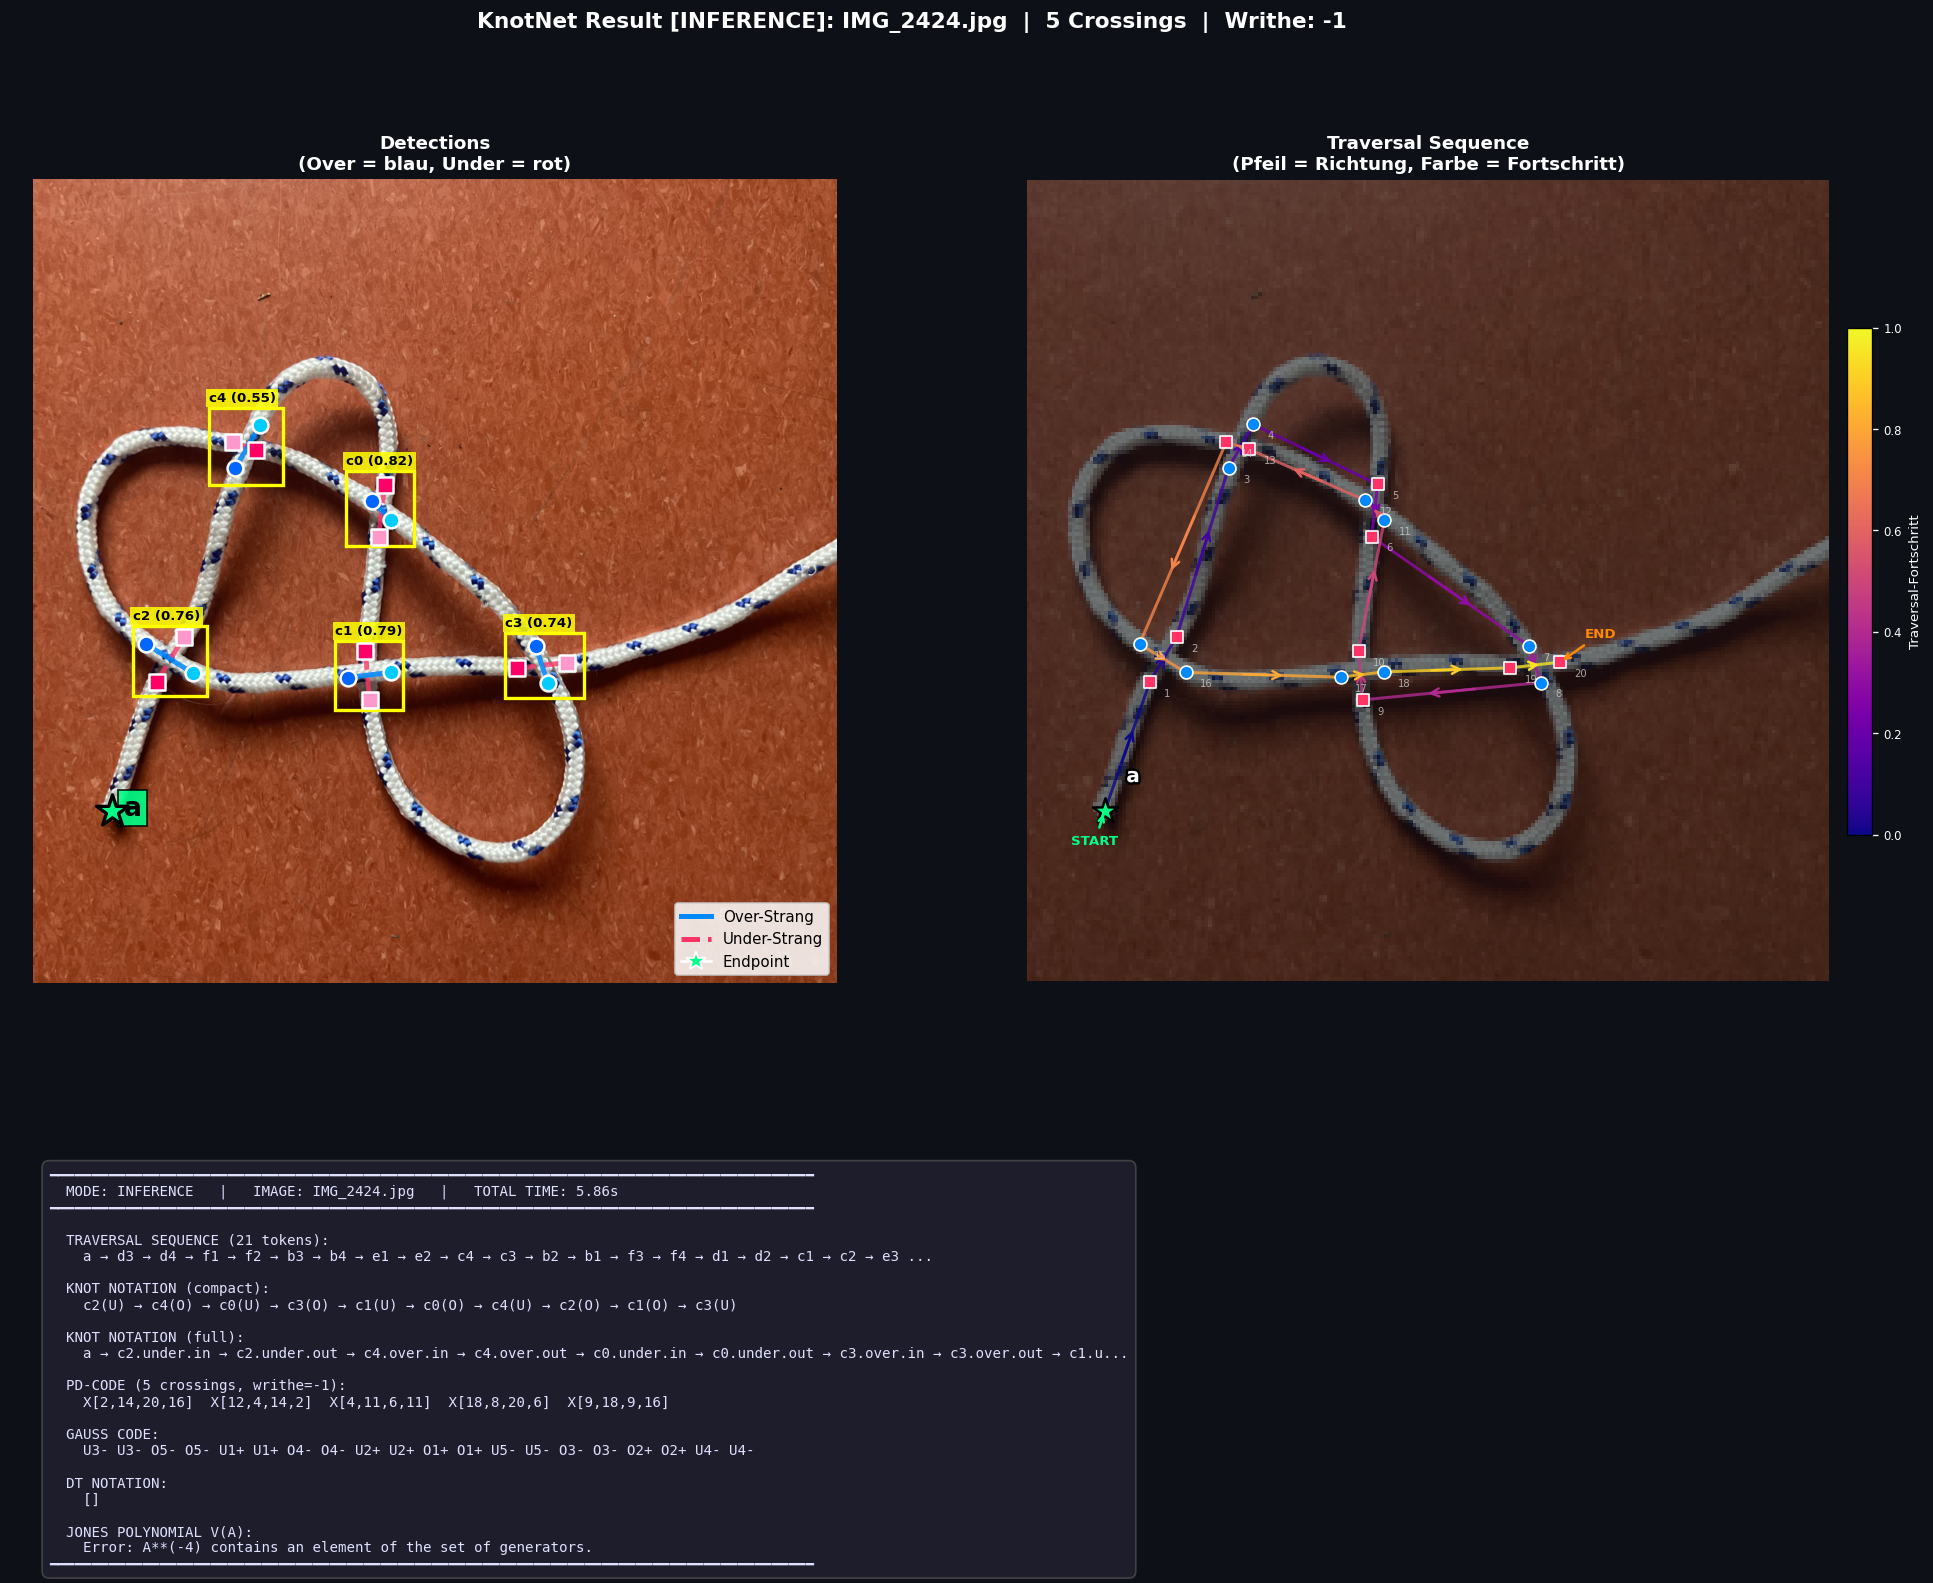

In [6]:
# Oder Visualisierung separat erzeugen
viz_path = pipe.visualize(result, "/Users/fregler001/Documents/10_uni/00_06_Semester/AI_project/repos/knot-cv/10_data/10_train/images/tom/IMG_2424.jpg")
print(f"Bild gespeichert: {viz_path}")

# Im Notebook direkt anzeigen:
from IPython.display import Image, display
display(Image(filename=str(viz_path)))

In [ ]:
# 3b) Gold Mode — GT Locations mitgeben
gt_locations = {
    "crossings": [
        {
            "crossing_idx": 0,
            "box_x": 412, "box_y": 305, "box_w": 95, "box_h": 88,
            "over_1_x": 420, "over_1_y": 320,
            "over_2_x": 495, "over_2_y": 340,
            "under_1_x": 445, "under_1_y": 298,
            "under_2_x": 460, "under_2_y": 385,
        },
        # ... weitere Crossings
    ],
    "endpoints": [
        {"x": 120, "y": 500},
        {"x": 880, "y": 150},
    ],
}

result_gold = pipe.run("path/to/image.jpg", gt_locations=gt_locations)
print(result_gold["mode"])  # "gold"
print(result_gold["sequence"])